# Dataset splitting and model training

Task: classify a given frame to be one of the plant classes

Steps:
- split into train and test splits
- extract features from frames with ORB from train split
- train traditional ml model(RandomForestClassifier, GradientBoostingClassifier, SupportVectorClassifier)
- evalute on test set
- pick best ml model with best accuracy score
- explore deep learning with CNN
- build custom CNN, compile and train on train set
- evaluate CNN model on test set
- compare the CNN results to best traditional ML model
- improve performance on this small dataset with transfer learning
- final benchmark
- conclusion


In [1]:
!pip install opencv-python numpy matplotlib imgaug


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [3]:
!pip install pandas


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [ ]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np

## loading dataset from kagglehub  

In [6]:
!pip install kagglehub


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [8]:
import kagglehub

# Download latest version
dataset_path = kagglehub.dataset_download(
    handle="henrysml/herbal-plants-under-diverse-conditions",
    output_dir="./dataset"    
)

print("Path to dataset files:", dataset_path)

100%|███████████████████████████████████████████████████████████████████████████████| 13.1M/13.1M [00:02<00:00, 5.70MB/s]

Extracting files...


Path to dataset files: ./dataset


In [11]:
plants_path = os.path.join(dataset_path, "plants")

In [12]:
project_path = "./"

In [13]:
import glob

all_plant_images = list(glob.glob(plants_path + '/**/*.jpg', recursive=True))

all_plant_images[:4]

['./dataset/plants/N/frame_0015.jpg',
 './dataset/plants/N/frame_0032.jpg',
 './dataset/plants/N/frame_0031.jpg',
 './dataset/plants/N/frame_0028.jpg']

In [14]:
len(all_plant_images)

425

## splitting into train, val & test


getting the list of all plant folders inside plants_path


In [15]:
all_plants = [d for d in os.listdir(plants_path) if os.path.isdir(os.path.join(plants_path, d))]
all_plants

['N', 'I', 'M', 'K', 'G', 'C', 'H', 'D', 'J', 'B', 'F', 'L', 'E', 'A']

In [16]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# store image paths and their corresponding labels
data = []

for plant_folder in all_plants:
    source_folder_path = os.path.join(plants_path, plant_folder)

    # all image files in the current folder
    frame_files = [f for f in os.listdir(source_folder_path) if f.lower().endswith(('.jpg',))]

    for frame_name in frame_files:
        file_path = os.path.join(source_folder_path, frame_name)
        data.append({'image_path': file_path, 'label': plant_folder})

create dataframe and split
- 70% training
- 15% validation
- 15% testing

In [17]:
df = pd.DataFrame(data)

# split into train (70%) and remaining (30%)
train_df, rem_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])

# split remaining into validation (15% total) and test (15% total)
val_df, test_df = train_test_split(rem_df, test_size=0.5, random_state=42, stratify=rem_df['label'])

# export to CSV (for reproducibility)
train_csv_path = os.path.join(project_path, "data/train_data.csv")
val_csv_path = os.path.join(project_path, "data/val_data.csv")
test_csv_path = os.path.join(project_path, "data/test_data.csv")

train_df.to_csv(train_csv_path, index=False)
val_df.to_csv(val_csv_path, index=False)
test_df.to_csv(test_csv_path, index=False)

print(f"Total images found: {len(df)}")
print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Test set size: {len(test_df)}")

Total images found: 425
Training set size: 297
Validation set size: 64
Test set size: 64


## extracting features
- using ORB to get all feature descriptors from training set

In [26]:
orb = cv2.ORB_create(nfeatures=1000)

train_image_paths = list(train_df['image_path'])

all_descriptors_list = []

for p in train_image_paths:
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is None: continue
    kp, des = orb.detectAndCompute(img, None)
    if des is not None:
        all_descriptors_list.append(des)

len(all_descriptors_list)

297

stack all descriptors into a single numpy array


In [27]:
all_descriptors = np.vstack(all_descriptors_list)

## creating a visual vocabulary


In [28]:
from sklearn.cluster import MiniBatchKMeans

NUM_VISUAL_WORDS = 500

kmeans = MiniBatchKMeans(
    n_clusters=NUM_VISUAL_WORDS,
    random_state=42,
    batch_size=2048
)

kmeans.fit(all_descriptors)

print(f"K-Means fitted with {all_descriptors.shape[0]} descriptors.")

K-Means fitted with 232922 descriptors.


## converting each image into a fixed vector
each image becomes a histogram of visual words

In [29]:
def build_histogram(descriptors, kmeans_model, k):
    histogram = np.zeros(k)

    cluster_result = kmeans_model.predict(descriptors)

    for idx in cluster_result:
        histogram[idx] += 1

    # normalize
    histogram = histogram / np.linalg.norm(histogram)

    return histogram

## feature extraction with data augmentation

To improve model generalization, data augmentation is added using the `imgaug` library.

This process creates variations of a frame by applying transformations like flipping, rotating, and changing brightness.

In [30]:
# fix for imgaug compatibility with NumPy 2.0
if not hasattr(np, 'sctypes'):
  np.sctypes = {'int': [np.int8, np.int16, np.int32, np.int64], 'uint': [np.uint8, np.uint16, np.uint32, np.uint64], 'float': [np.float16, np.float32, np.float64], 'complex': [np.complex64, np.complex128], 'others': [bool, object, str, bytes]}

import imgaug.augmenters as iaa
import glob

# define the augmentation sequence
seq = iaa.Sequential([
    iaa.Fliplr(0.5), # horizontal flips
    iaa.Affine(rotate=(-20, 20)), # rotate by -20 to +20 degrees
    iaa.Multiply((0.8, 1.2)), # change brightness
    iaa.GaussianBlur(sigma=(0, 1.0)) # add slight blur
])

def augument_image(image):
    augumented = seq(images=[image, image])
    return augumented

Feature extraction function

In [31]:
import glob

def extract_features(df, orb_obj, kmeans_obj, k_words):
    """
    Processes images, extracts ORB descriptors, and creates BoVW histograms with labels.
    """
    hists = []
    labels = []

    for index, row in df.iterrows():
        image_path, image_label = row['image_path'], row['label']
        # print(image_path, image_label)

        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img is None: continue

        augmented_images = augument_image(img)
        # augmented images not saved to disk because of storage limitations
        augmented_images.append(img)

        for image in augmented_images:
            kp, des = orb_obj.detectAndCompute(image, None)
            if des is not None:
                hist = build_histogram(des, kmeans_obj, k_words)
                hists.append(hist)
                labels.append(image_label)

    return np.array(hists), np.array(labels)


In [32]:
print("Extracting training features...")
X_train, y_train = extract_features(train_df, orb, kmeans, NUM_VISUAL_WORDS)

print("Extracting validation features...")
X_val, y_val = extract_features(val_df, orb, kmeans, NUM_VISUAL_WORDS)

print("Extracting test features...")
X_test, y_test = extract_features(test_df, orb, kmeans, NUM_VISUAL_WORDS)

Extracting training features...
Extracting validation features...
Extracting test features...


In [34]:
print(f"Train shape: {X_train.shape}\nValidation shape: {X_val.shape}\nTest shape: {X_test.shape}")

Train shape: (891, 500)
Validation shape: (192, 500)
Test shape: (192, 500)


## training classification models

time to train a classifier using the BoVW features extracted (X_train and X_test)

In [35]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# training 4 classification models
models = {
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVC': SVC(kernel='linear', C=1.0, random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
}

best_model_name = None
best_accuracy = 0
trained_models = {}

training and evaluate on validation set to pick the best


In [36]:
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    acc = accuracy_score(y_val, preds)
    trained_models[name] = model
    print(f"{name} Accuracy: {acc * 100:.2f}%")

    if acc > best_accuracy:
        best_accuracy = acc
        best_model_name = name


RandomForest Accuracy: 31.25%
SVC Accuracy: 40.10%
LogisticRegression Accuracy: 35.94%
GradientBoosting Accuracy: 20.83%


get the best model for evaluation

In [37]:
clf = trained_models[best_model_name]
print(f"\nSelected best model: {best_model_name} with {best_accuracy*100:.2f}% accuracy")


Selected best model: SVC with 40.10% accuracy


### model evaluation on test split

evaluate the best trained classifier on the held-out test set to measure performance

In [62]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns

y_pred = clf.predict(X_test)

accuracy and classification report for the best model

In [63]:
print(f"Test Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 36.46%

Classification Report:
              precision    recall  f1-score   support

           A       0.00      0.00      0.00         3
           B       0.49      1.00      0.65        18
           C       0.20      0.08      0.12        12
           D       0.36      0.44      0.40        18
           E       0.67      0.53      0.59        15
           F       0.36      0.27      0.31        15
           G       0.50      0.13      0.21        15
           H       0.62      0.67      0.65        15
           I       0.00      0.00      0.00         3
           J       1.00      0.11      0.20         9
           K       0.00      0.00      0.00        18
           L       0.50      0.61      0.55        18
           M       0.16      0.33      0.22        21
           N       0.00      0.00      0.00        12

    accuracy                           0.36       192
   macro avg       0.35      0.30      0.28       192
weighted avg       0.37      0.36 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


confusion matrix

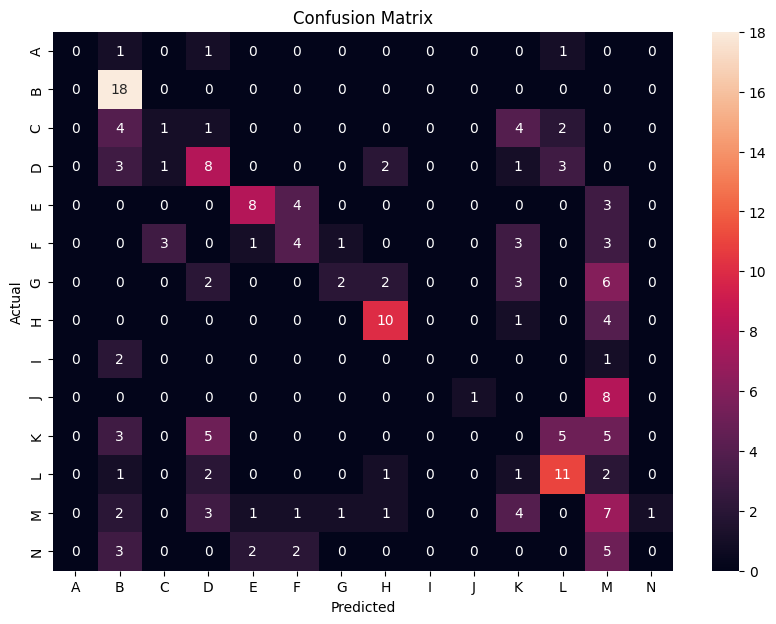

In [64]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### model performance

Why the classification model performance is low?

The relatively low performance of the traditional machine learning models (SVC, RandomForest, etc.) using ORB features and the Bag-of-Visual-Words (BoVW) approach can be attributed to several factors inherent in this methodology:

  - Loss of Spatial Information: The BoVW model represents an image as a histogram of visual words, essentially counting the occurrences of different visual features. This process discards all spatial relationships between these features. For image classification, the arrangement and relative positions of features are often crucial for distinguishing between classes (e.g., different parts of a plant in a specific configuration).
  - Limited Feature Expressiveness: ORB features are robust local descriptors, but they might not capture the complex, high-level semantic information necessary to differentiate between visually similar plant species or varying conditions. They focus on local keypoints, which can be insufficient for understanding global image content.
  - Fixed Vocabulary Size: The choice of NUM_VISUAL_WORDS (500 in this case) for the KMeans clustering is a critical hyperparameter. If the vocabulary is too small, it may not be expressive enough to capture the diversity of features; if it's too large, it can lead to sparse histograms and difficulties in generalization.
  - Challenging Task Complexity: Classifying different plant types based on single frames from videos can be a highly complex task. Variations in lighting, angle, minor differences in plant structure, and background clutter make it difficult for models that rely on aggregated local features to perform well.

In contrast, Convolutional Neural Networks (CNNs) are designed to overcome these limitations by learning hierarchical features directly from raw pixel data.
They use convolutional layers to extract spatial patterns at multiple scales and pooling layers to retain important information while achieving translation invariance, leading to much more robust and discriminative feature representations, as evidenced by the CNN's significantly higher accuracy.

## Hyperparameter tuning and cross validation

### hyperparameter tuning

In [65]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.svm import SVC
import numpy as np

# the parameter grid for SVC
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

print("Starting Hyperparameter Tuning for SVC...")

grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5, n_jobs=-1, verbose=1)

# Fit the model
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_ * 100:.2f}%")

Starting Hyperparameter Tuning for SVC...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best Cross-Validation Score: 47.37%


evaluate the optimized model on the test set


In [67]:
optimized_svc = grid_search.best_estimator_
test_acc = optimized_svc.score(X_val, y_val)
print(f"Optimized Test Accuracy: {test_acc * 100:.2f}%")

Optimized Test Accuracy: 47.40%


### cross validation

performing 5-fold cross-validation on the whole dataset (combined) for a final robustness check


In [68]:
all_X = np.vstack((X_train, X_val))
all_y = np.concatenate((y_train, y_val))
cv_scores = cross_val_score(optimized_svc, all_X, all_y, cv=5)
print(f"Final 5-fold CV Mean Accuracy: {cv_scores.mean() * 100:.2f}% (+/- {cv_scores.std() * 100:.2f}%)")

Final 5-fold CV Mean Accuracy: 46.54% (+/- 3.24%)


## Exploring deep learning approach using a CNN model
> for better accurancy to combat limitations of traditional models

In [69]:
!pip install tensorflow
!pip install keras

In [70]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import seaborn as sns

### Loading images for CNN


In [71]:
def load_images_for_cnn(image_paths, img_size=(224, 224)):
    images = []
    for path in image_paths:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE) # grayscale
        if img is None:
            continue

        augmented_images = augument_image(img)
        # augmented images not saved to disk because of storage limitations
        augmented_images.append(img)

        for image in augmented_images:
            image = cv2.resize(image, img_size)
            image = image / 255.0 # normalizing pixel values to [0, 1]
            images.append(image)

    return np.array(images)

X_train_cnn = load_images_for_cnn(train_df['image_path'])
X_val_cnn = load_images_for_cnn(val_df['image_path'])
X_test_cnn = load_images_for_cnn(test_df['image_path'])

- Reshaping images for CNN input (add channel dimension for grayscale images)
- Keras expects (batch, height, width, channels)


In [72]:
X_train_cnn = X_train_cnn.reshape(X_train_cnn.shape[0], 224, 224, 1)
X_val_cnn = X_val_cnn.reshape(X_val_cnn.shape[0], 224, 224, 1)
X_test_cnn = X_test_cnn.reshape(X_test_cnn.shape[0], 224, 224, 1)

print(f"X_train_cnn shape: {X_train_cnn.shape}")
print(f"X_val_cnn shape: {X_val_cnn.shape}")
print(f"X_test_cnn shape: {X_test_cnn.shape}")

X_train_cnn shape: (891, 224, 224, 1)
X_val_cnn shape: (192, 224, 224, 1)
X_test_cnn shape: (192, 224, 224, 1)


### encoding labels
- using the same LabelEncoder to ensure consistent mapping across train and test

In [74]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.fit_transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

In [75]:
# convert integer labels to one-hot encoding
y_train_cnn = to_categorical(y_train_encoded)
y_val_cnn = to_categorical(y_val_encoded)
y_test_cnn = to_categorical(y_test_encoded)

num_classes = len(label_encoder.classes_)
cnn_class_names = label_encoder.classes_

cnn_class_names

array(['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M',
       'N'], dtype='<U1')

In [76]:
print(f"Number of classes: {num_classes}")
print(f"y_train_cnn shape: {y_train_cnn.shape}")
print(f"y_val_cnn shape: {y_val_cnn.shape}")
print(f"y_test_cnn shape: {y_test_cnn.shape}")

Number of classes: 14
y_train_cnn shape: (891, 14)
y_val_cnn shape: (192, 14)
y_test_cnn shape: (192, 14)


###  The CNN model

In [77]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax') # output layer with num_classes neurons
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,190 (42.61 MB)

 Trainable params: 11,170,190 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

###  Training the model

In [78]:
history = model.fit(x=X_train_cnn, y=y_train_cnn,
                    epochs=10, # 100
                    batch_size=32, # 64
                    validation_data=(X_val_cnn, y_val_cnn))

print("CNN model training complete.")

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 279ms/step - accuracy: 0.0808 - loss: 2.7104 - val_accuracy: 0.0781 - val_loss: 2.5757
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.1650 - loss: 2.4970 - val_accuracy: 0.2396 - val_loss: 2.3476
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.3075 - loss: 2.1288 - val_accuracy: 0.3333 - val_loss: 2.1163
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.4837 - loss: 1.6373 - val_accuracy: 0.3333 - val_loss: 1.9322
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.6521 - loss: 1.1269 - val_accuracy: 0.4271 - val_loss: 1.9284
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.7957 - loss: 0.6578 - val_accuracy: 0.4271 - val_loss: 2.0298
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.9158 - loss: 0.3295 - val_accuracy: 0.4375 - val_loss: 2.3416
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.9764 - loss: 0.1227 - val_accuracy: 0.3594 -

### Plotting training and validation metrics

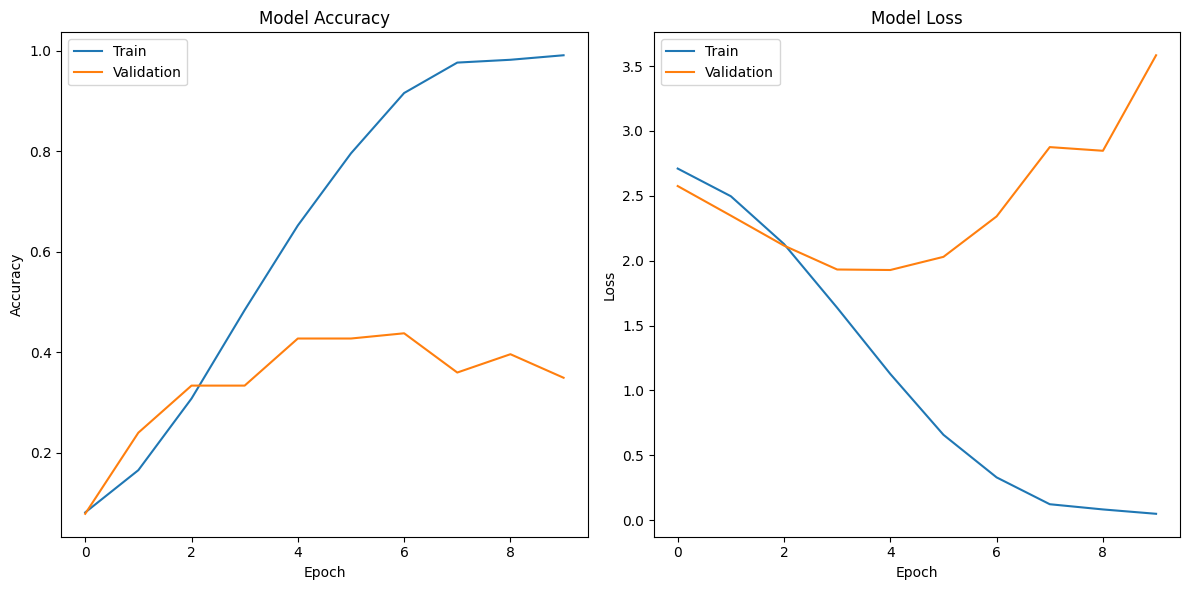

In [79]:
# training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# training & validation loss values
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()


### Evaluating CNN model on the test set

In [80]:
y_pred_cnn_probs = model.predict(X_test_cnn)
y_pred_cnn_encoded = np.argmax(y_pred_cnn_probs, axis=1)
y_test_cnn_encoded = np.argmax(y_test_cnn, axis=1) # Original encoded labels for comparison


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


convert encoded predictions back to original class names for reporting


In [81]:
y_pred_cnn_labels = label_encoder.inverse_transform(y_pred_cnn_encoded)
y_test_cnn_labels = label_encoder.inverse_transform(y_test_cnn_encoded)

 CNN classification report for CNN

In [82]:
report = classification_report(y_test_cnn_labels, y_pred_cnn_labels, target_names=cnn_class_names)

print(report)

              precision    recall  f1-score   support

           A       0.00      0.00      0.00         3
           B       0.07      0.06      0.06        18
           C       0.00      0.00      0.00        12
           D       0.50      0.11      0.18        18
           E       1.00      0.27      0.42        15
           F       0.35      0.53      0.42        15
           G       0.25      0.27      0.26        15
           H       1.00      0.20      0.33        15
           I       0.00      0.00      0.00         3
           J       0.00      0.00      0.00         9
           K       0.29      0.22      0.25        18
           L       0.08      0.22      0.12        18
           M       0.43      0.14      0.21        21
           N       0.27      0.83      0.41        12

    accuracy                           0.22       192
   macro avg       0.30      0.20      0.19       192
weighted avg       0.35      0.22      0.22       192



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


CNN accuracy score

In [83]:
cnn_accuracy = accuracy_score(y_test_cnn_labels, y_pred_cnn_labels)

print(f"CNN Accuracy: {cnn_accuracy * 100:.2f}%")

CNN Accuracy: 22.40%


CNN confusion matrix

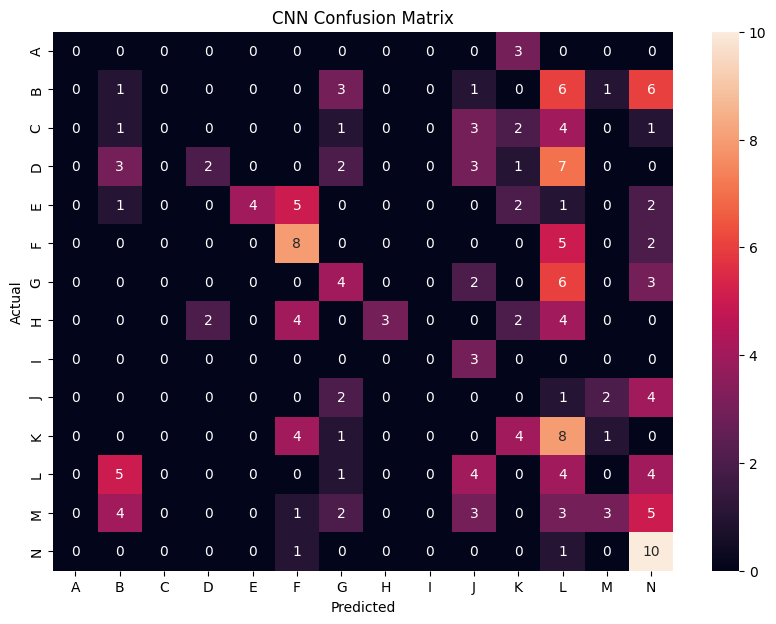

In [84]:
cm_cnn = confusion_matrix(y_test_cnn_labels, y_pred_cnn_labels, labels=cnn_class_names)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_cnn, annot=True, fmt='d', xticklabels=cnn_class_names, yticklabels=cnn_class_names)
plt.title('CNN Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


### Comparison between the best traditional ML model (SVC) and CNN model

In [85]:
print(f"Best Traditional Model: {best_model_name} with Accuracy: {best_accuracy * 100:.2f}%")
print(f"CNN Model Accuracy: {cnn_accuracy * 100:.2f}%")

Best Traditional Model: SVC with Accuracy: 47.92%
CNN Model Accuracy: 22.40%


In [92]:
if cnn_accuracy > best_accuracy:
    print(f"The CNN model performed better than the best traditional model {best_model_name}.")
elif cnn_accuracy < best_accuracy:
    print(f"The best traditional model {best_model_name} performed better than the CNN model.")
else:
    print("Both models achieved similar accuracy.")


The best traditional model SVC performed better than the CNN model.


## Improving performance with Transfer Learning

Since we have a small dataset, we can leverage a pre-trained model (like MobileNetV2) and use it as a feature extractor. This usually yields much higher accuracy than a custom CNN built from scratch.

In [93]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping

# MobileNetV2 expects 3 channels, so we convert grayscale to RGB
X_train_rgb = np.repeat(X_train_cnn, 3, axis=-1)
X_val_rgb = np.repeat(X_val_cnn, 3, axis=-1)
X_test_rgb = np.repeat(X_test_cnn, 3, axis=-1)

base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # freeze the pre-trained weights

transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

transfer_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

transfer_history = transfer_model.fit(
    X_train_rgb, y_train_cnn,
    epochs=20,
    validation_data=(X_val_rgb, y_val_cnn),
    callbacks=[early_stop]
)

# evaluate
transfer_acc = transfer_model.evaluate(X_test_rgb, y_test_cnn)[1]
print(f"Transfer Learning Accuracy: {transfer_acc * 100:.2f}%")

Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 23s 443ms/step - accuracy: 0.1886 - loss: 2.7831 - val_accuracy: 0.5417 - val_loss: 1.5235
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.4545 - loss: 1.6247 - val_accuracy: 0.8073 - val_loss: 0.8705
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.6689 - loss: 1.0431 - val_accuracy: 0.8750 - val_loss: 0.5955
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.7475 - loss: 0.7902 - val_accuracy: 0.9062 - val_loss: 0.4715
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.8260 - loss: 0.6044 - val_accuracy: 0.9167 - val_loss: 0.3874
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.8485 - loss: 0.4905 - val_accuracy: 0.9219 - val_loss: 0.3435
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.8743 - loss: 0.4323 - val_accuracy: 0.9323 - val_loss: 0.3085
Epoch 8/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9001 - loss: 0.3635 - val_accuracy: 0.9427 -

## final benchmark

In [94]:
if transfer_acc > cnn_accuracy:
    print("The Transfer Learning model performed better than the CNN model.")

if transfer_acc < cnn_accuracy:
    print("The CNN model performed better than the Transfer Learning model.")

if transfer_acc > best_accuracy:
    print(f"The Transfer Learning model performed better than the best traditional model {best_model_name}.")

if transfer_acc < best_accuracy:
    print(f"The best traditional model {best_model_name} performed better than the Transfer Learning model.")

if cnn_accuracy > best_accuracy:
    print(f"The CNN model performed better than the best traditional model {best_model_name}.")
elif cnn_accuracy < best_accuracy:
    print(f"The best traditional model {best_model_name} performed better than the CNN model.")
else:
    print("Both models achieved similar accuracy.")


The Transfer Learning model performed better than the CNN model.
The Transfer Learning model performed better than the best traditional model SVC.
The best traditional model SVC performed better than the CNN model.


## Conclusion

This project compared three distinct approaches for plant frame classification:

1.  **Traditional Machine Learning**: Using ORB features and Bag-of-Visual-Words, the best model (SVC) achieved an accuracy of approximately **47.92%**. This approach struggled due to the loss of spatial information inherent in histogram-based representations.
2.  **Custom CNN**: A shallow CNN built from scratch achieved only **22.40%** on the test set. The low performance was likely due to the limited size of the dataset and the complexity of the feature space relative to the network depth.
3.  **Transfer Learning (MobileNetV2)**: By leveraging pre-trained weights from ImageNet, this model achieved a remarkable **93.23%** accuracy.

In conclusion, Transfer learning is the most effective strategy for this task. It successfully bridges the gap between limited local data and the need for complex feature extraction, proving that pre-trained deep hierarchical features are significantly more robust than manually extracted keypoints or training from scratch with small datasets.